# Quantum teleportation

Alice sends an unknown one-qubit state to Bob with a shared Bell pair and two classical bits. The code lives in `src/teleportation.py`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from qiskit.visualization import plot_bloch_multivector

from src.teleportation import random_message, teleport, teleportation_circuit

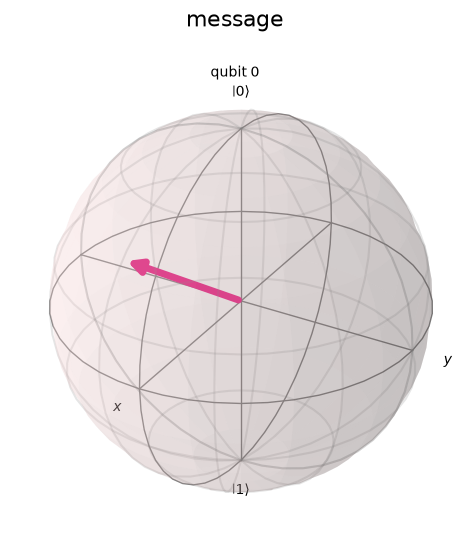

In [2]:
message = random_message(seed=11)
plot_bloch_multivector(message, title="message")

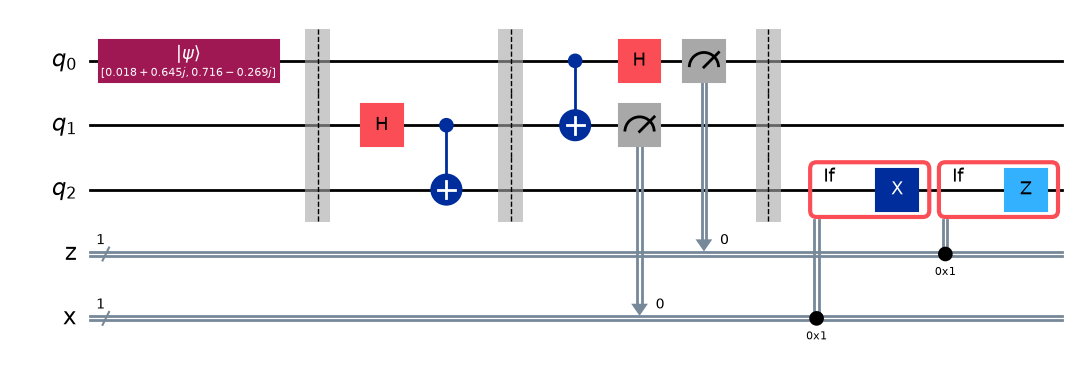

In [3]:
teleportation_circuit(message).draw("mpl")

## Run it a few times

Alice's two bits come out random, so different runs take different branches of Bob's corrections. The fidelity should be 1 on every run.

In [4]:
for seed in range(6):
    r = teleport(message, seed=seed)
    print(f"seed {seed}: z={r.z_bit} x={r.x_bit}  fidelity={r.fidelity:.6f}")

seed 0: z=1 x=0  fidelity=1.000000
seed 1: z=0 x=0  fidelity=1.000000
seed 2: z=1 x=1  fidelity=1.000000
seed 3: z=0 x=1  fidelity=1.000000


seed 4: z=0 x=1  fidelity=1.000000
seed 5: z=0 x=0  fidelity=1.000000


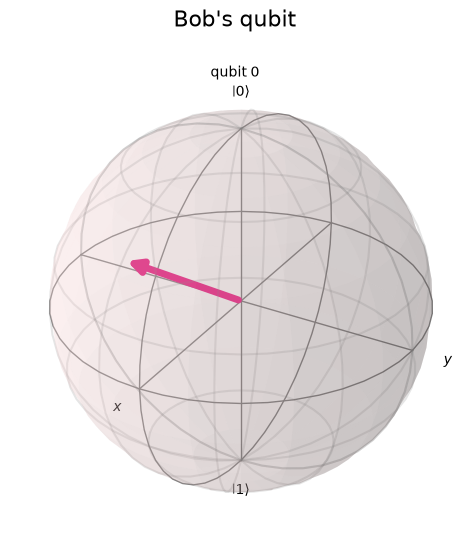

In [5]:
result = teleport(message, seed=0)
plot_bloch_multivector(result.received, title="Bob's qubit")